# 01 - Dataset Inspection

**Day 1 - Cross-Temporal Hybrid NIDS**

Purpose: explore the raw CIC-IDS2017 files *without* loading the full
dataset into memory, and demonstrate the discovery/validation utilities
that live in `src/`.

This notebook is for **exploration and academic demonstration only**.
All real logic (file discovery, chunked reading, schema/NaN-Inf
validation) lives in `src/data/` and is only *called* here, never
re-implemented.

> **Resource note:** every cell below reads at most one chunk of the
> dataset (default 250,000 rows or fewer). Nothing here concatenates the
> full CIC-IDS2017 dataset into a single in-memory DataFrame.

> **Status:** this notebook has **not** been executed against the real
> dataset. Run it yourself after placing CIC-IDS2017 files under
> `data/raw/CIC-IDS2017/{parquet,csv}/`.

In [2]:
import sys
import numpy
import pandas
import sklearn
import pyarrow

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyArrow:", pyarrow.__version__)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
NumPy: 2.0.2
Pandas: 2.2.3
Scikit-learn: 1.5.2
PyArrow: 25.0.1


In [3]:
# --- Setup -----------------------------------------------------------
from __future__ import annotations

import json
import sys
from pathlib import Path

# Make the project root importable (notebooks/ -> project root)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import (
    discover_dataset_files,
    iter_dataset_chunks,
    peek_schema,
    DEFAULT_CHUNK_SIZE,
)
from src.data.validator import validate_schema, validate_nan_inf
from src.data.temporal_split import detect_timestamp_column

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "CIC-IDS2017"
RAW_DIR

WindowsPath('c:/Users/abuba/Downloads/Network-Intrusion-Detection-System-NIDS-/data/raw/CIC-IDS2017')

## 1. Dataset discovery

Uses `src.data.loader.discover_dataset_files` to scan for Parquet and CSV
files under `data/raw/CIC-IDS2017/`. This never downloads anything - it
only looks at files already on disk.

In [4]:
dataset = discover_dataset_files(RAW_DIR)

print(f"Preferred format : {dataset.preferred_format}")
print(f"Has parquet      : {dataset.has_parquet}")
print(f"Has csv          : {dataset.has_csv}")
print(f"Is empty         : {dataset.is_empty}")

Preferred format : parquet
Has parquet      : True
Has csv          : False
Is empty         : False


## 2. Available CIC-IDS2017 files

The full, sorted list of files discovered on disk (whichever format is
present).

In [5]:
print(f"Parquet files ({len(dataset.parquet_files)}):")
for p in dataset.parquet_files:
    print(f"  - {p}")

print(f"\nCSV files ({len(dataset.csv_files)}):")
for p in dataset.csv_files:
    print(f"  - {p}")

Parquet files (8):
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\Benign-Monday-no-metadata.parquet
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\Botnet-Friday-no-metadata.parquet
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\Bruteforce-Tuesday-no-metadata.parquet
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\DDoS-Friday-no-metadata.parquet
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\DoS-Wednesday-no-metadata.parquet
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\Infiltration-Thursday-no-metadata.parquet
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\Portscan-Friday-no-metadata.parquet
  - c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\raw\CIC-IDS2017\We

## 3. Dataset shape (schema peek, not a full load)

`peek_schema` reads only a handful of rows purely to inspect columns -
it never materializes the whole dataset.

In [6]:
sample = peek_schema(RAW_DIR, n_rows=10)
print(f"Peeked sample shape: {sample.shape}")
sample.head()

Peeked sample shape: (10, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


## 4. Column names and data types

`validate_schema` reports the schema of a single in-memory chunk. It
never renames or drops anything - only reports.

In [7]:
schema_report = validate_schema(sample)

print(f"n_columns             : {schema_report.n_columns}")
print(f"detected_label_column : {schema_report.detected_label_column!r}")
print(f"duplicate_columns     : {schema_report.duplicate_columns}")
print(f"unnamed_columns       : {schema_report.unnamed_columns}")
print()
print("Columns and dtypes:")
for col, dt in schema_report.dtypes.items():
    print(f"  {col:40s} {dt}")

n_columns             : 78
detected_label_column : 'Label'
duplicate_columns     : []
unnamed_columns       : []

Columns and dtypes:
  Protocol                                 int64
  Flow Duration                            int64
  Total Fwd Packets                        int64
  Total Backward Packets                   int64
  Fwd Packets Length Total                 int64
  Bwd Packets Length Total                 int64
  Fwd Packet Length Max                    int64
  Fwd Packet Length Min                    int64
  Fwd Packet Length Mean                   float32
  Fwd Packet Length Std                    float32
  Bwd Packet Length Max                    int64
  Bwd Packet Length Min                    int64
  Bwd Packet Length Mean                   float32
  Bwd Packet Length Std                    float32
  Flow Bytes/s                             float64
  Flow Packets/s                           float64
  Flow IAT Mean                            float32
  Flow IAT Std     

## 5. Read one full chunk

For label distribution / missing / infinite value checks we need a
representative sample larger than the schema peek, but still just
**one bounded chunk** (default `DEFAULT_CHUNK_SIZE` rows), never the
whole dataset.

In [8]:
first_chunk = next(iter_dataset_chunks(RAW_DIR, chunk_size=DEFAULT_CHUNK_SIZE))
print(f"Chunk shape: {first_chunk.shape}")
first_chunk.head()

Chunk shape: (250000, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


## 6. Label distribution

Using the label column detected in step 4.

In [9]:
label_col = schema_report.detected_label_column
assert label_col is not None, "No label column detected - inspect the raw files."

label_counts = first_chunk[label_col].value_counts()
label_counts

Label
Benign    250000
Name: count, dtype: int64

## 7. Missing values

`validate_nan_inf` counts NaNs per column for the chunk in memory.

In [10]:
nan_inf_report = validate_nan_inf(first_chunk)

missing_series = pd.Series(nan_inf_report.nan_counts).sort_values(ascending=False)
missing_series[missing_series > 0]

Series([], dtype: int64)

## 8. Infinite values

CIC-IDS2017 is known to contain +/-Inf values (e.g. in flow-rate
features from zero-duration flows). This step surfaces them without
modifying anything.

In [11]:
inf_series = pd.Series(nan_inf_report.inf_counts).sort_values(ascending=False)
inf_series[inf_series > 0]

Series([], dtype: int64)

## 9. Timestamp discovery

`detect_timestamp_column` scans column names for known hints
(`timestamp`, `flow start`, ...) and validates that the values are
parseable as datetimes. This is a prerequisite for the temporal split
demonstrated in `03_temporal_split.ipynb`.

In [12]:
ts_result = detect_timestamp_column(first_chunk)

print(f"Detected column     : {ts_result.column!r}")
print(f"Parsed successfully : {ts_result.parsed_successfully}")
print(f"Unparseable values  : {ts_result.n_unparseable}")
for note in ts_result.notes:
    print(f"  note: {note}")

No timestamp-like column detected by name. Row-level chronological splitting cannot proceed without an explicit timestamp column.


Detected column     : None
Parsed successfully : False
Unparseable values  : 0
  note: No timestamp-like column detected by name. Row-level chronological splitting cannot proceed without an explicit timestamp column.


## 10. Basic visualizations

Simple, cheap plots over the single in-memory chunk - no aggregation
across the full dataset.

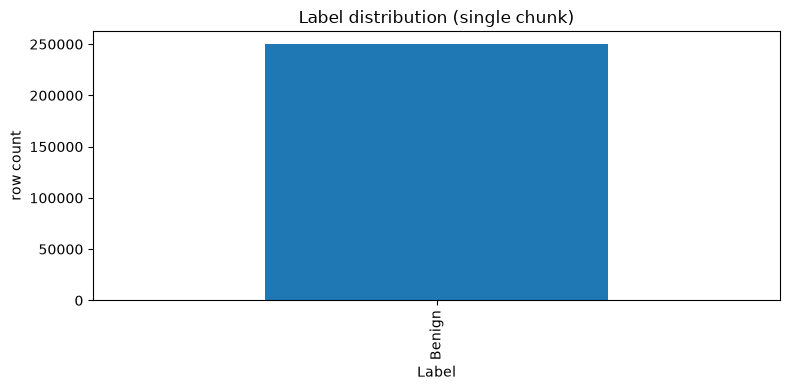

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
label_counts.plot(kind="bar", ax=ax)
ax.set_title("Label distribution (single chunk)")
ax.set_xlabel(label_col)
ax.set_ylabel("row count")
plt.tight_layout()
plt.show()

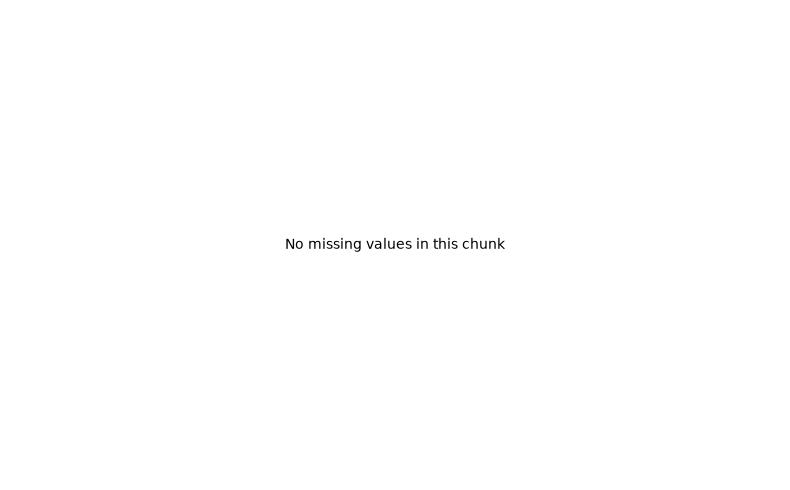

In [14]:
top_missing = missing_series[missing_series > 0].head(20)

fig, ax = plt.subplots(figsize=(8, 5))
if len(top_missing) > 0:
    top_missing.plot(kind="barh", ax=ax)
    ax.set_title("Top columns by missing-value count (single chunk)")
    ax.set_xlabel("NaN count")
else:
    ax.text(0.5, 0.5, "No missing values in this chunk", ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## Summary

* Dataset files discovered and listed (Parquet-preferred, CSV fallback).
* Shape / columns / dtypes inspected via a small schema peek.
* Label distribution, missing values, and infinite values checked on one
  bounded chunk.
* Timestamp column detected for use in `03_temporal_split.ipynb`.

Next: `02_data_preprocessing.ipynb` for cleaning, leakage checks, and
feature selection.